# 10c — Agreement Metric Reliability

Focused evaluation of the metrics used in nb10 for measuring inter-rater agreement on free-text VQA answers.

**Questions answered here:**
- How correlated are the metrics with each other?
- How sensitive is each metric to answer length?
- How well does each metric separate HH / MM / HM pair types (discriminability)?
- Which metric correlates best with human question difficulty?
- Are any metrics redundant or unreliable for short VQA answers?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

BASE    = Path('../../')
EXPORTS = Path('exports')

METRICS = ['exact', 'jaccard', 'rouge1', 'chrf', 'sbert', 'simcse', 'bertscore']
METRIC_COLS = {
    'exact':     'exact_score',
    'jaccard':   'jaccard_score',
    'rouge1':    'rouge1_score',
    'chrf':      'chrf_score',
    'sbert':     'sbert_score_clip',
    'simcse':    'simcse_score_clip',
    'bertscore': 'bertscore_f1',
}
PAIR_TYPES   = ['HH', 'MM', 'HM']
VARIANT_ORDER = ['C', 'B', 'A']

COLORS = {'HH': '#333333', 'MM': '#9C27B0', 'HM': '#FF5722'}
METRIC_COLORS = {
    'exact': '#1565C0', 'jaccard': '#1976D2', 'rouge1': '#42A5F5',
    'chrf': '#26C6DA', 'sbert': '#388E3C', 'simcse': '#66BB6A', 'bertscore': '#EF6C00',
}

In [2]:
# ── Load pair cache (all metrics, all variants) ───────────────────────────────
# The pair cache from nb10 already contains only free-text pairs —
# nb10 processes text_qids exclusively; yes/no pairs are handled in nb10b.
pairs = pd.read_parquet(EXPORTS / 'pair_cache.parquet')

# Rename metric columns to short names for convenience
for name, col in METRIC_COLS.items():
    if col in pairs.columns:
        pairs[name] = pairs[col]

# Answer length (token count)
pairs['len1'] = pairs['answer_1'].fillna('').str.split().str.len()
pairs['len2'] = pairs['answer_2'].fillna('').str.split().str.len()
pairs['len_min'] = pairs[['len1', 'len2']].min(axis=1)
pairs['len_max'] = pairs[['len1', 'len2']].max(axis=1)
pairs['len_mean'] = (pairs['len1'] + pairs['len2']) / 2

C = pairs[pairs['variant'] == 'C'].copy()
print(f'Pairs loaded: {len(pairs):,}  (variant C: {len(C):,})')
print(f'Answer length (tokens): mean={pairs["len_mean"].mean():.1f}, '
      f'median={pairs["len_mean"].median():.0f}, max={pairs["len_max"].max()}')
print(f'Metrics available: {[m for m in METRICS if m in pairs.columns]}')

Pairs loaded: 434,950  (variant C: 145,199)
Answer length (tokens): mean=6.0, median=1, max=367
Metrics available: ['exact', 'jaccard', 'rouge1', 'chrf', 'sbert', 'simcse', 'bertscore']


## 1. Score distributions

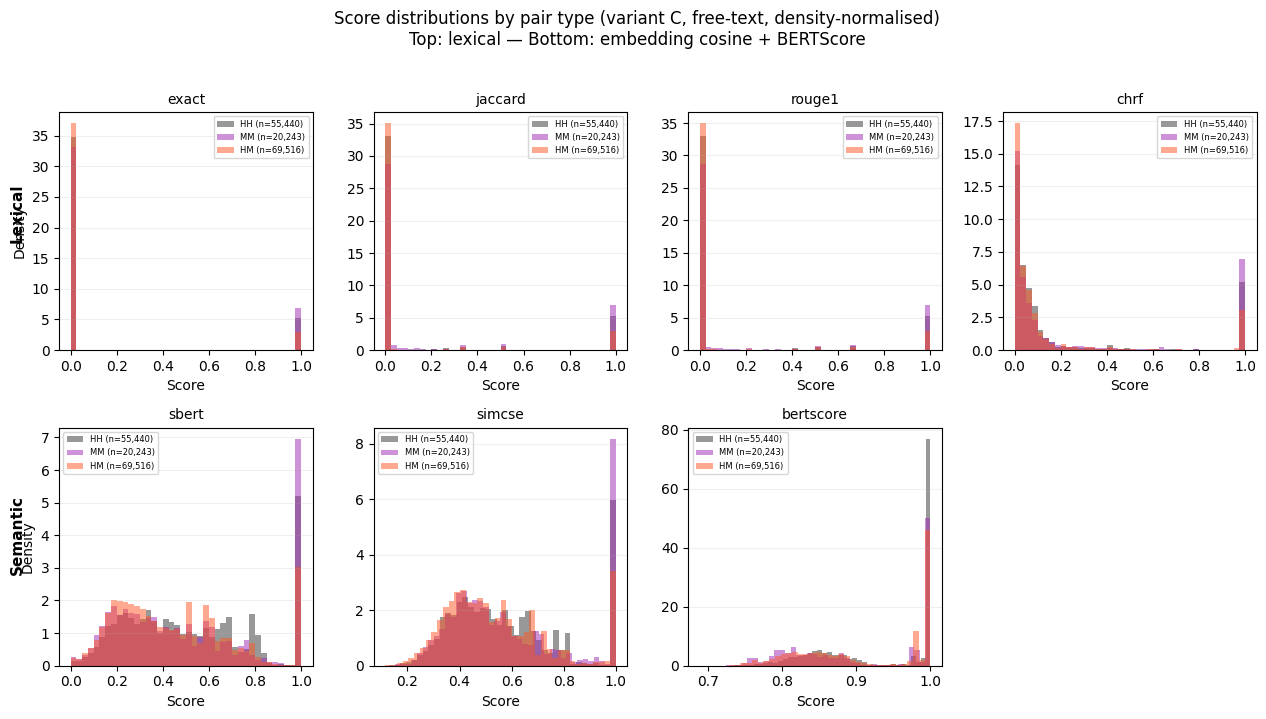

n_pairs   mean    std    p10    p90
tier     metric    pair_type                                     
lexical  exact     HH           55440  0.130  0.337  0.000  1.000
                   MM           20243  0.173  0.378  0.000  1.000
                   HM           69516  0.076  0.264  0.000  0.000
         jaccard   HH           55440  0.146  0.340  0.000  1.000
                   MM           20243  0.199  0.378  0.000  1.000
                   HM           69516  0.090  0.271  0.000  0.333
         rouge1    HH           55440  0.153  0.346  0.000  1.000
                   MM           20243  0.210  0.384  0.000  1.000
                   HM           69516  0.097  0.278  0.000  0.500
         chrf      HH           55440  0.191  0.331  0.000  1.000
                   MM           20243  0.236  0.371  0.000  1.000
                   HM           69516  0.137  0.277  0.000  0.447
semantic sbert     HH           55440  0.512  0.274  0.183  1.000
                   MM           20243  0.493  0.297  0.159  1.000
                   HM           69516  0.438  0.250  0.162  0.776
         simcse    HH           55440  0.583  0.216  0.343  1.000
                   MM           20243  0.592  0.233  0.341  1.000
                   HM           69516  0.536  0.197  0.325  0.822
         bertscore HH           55440  0.933  0.078  0.822  1.000
                   MM           20243  0.905  0.089  0.790  1.000
                   HM           69516  0.912  0.085  0.799  1.000

In [3]:
# ── Score distributions: lexical vs semantic metrics, variant C ───────────────
avail = [m for m in METRICS if m in C.columns]

LEX_METRICS = [m for m in avail if m in ('exact', 'jaccard', 'rouge1', 'chrf')]
SEM_METRICS = [m for m in avail if m in ('sbert', 'simcse', 'bertscore')]

# Pair counts per type (for annotation — density=True normalises shapes but counts matter for noise)
pair_counts = {pt: len(C[C['pair_type'] == pt]) for pt in PAIR_TYPES}

def plot_distribution_row(axes_row, metrics):
    for ax, m in zip(axes_row, metrics):
        for pt in PAIR_TYPES:
            vals = C[C['pair_type'] == pt][m].dropna()
            ax.hist(vals, bins=40, alpha=0.5, color=COLORS[pt], label=f'{pt} (n={pair_counts[pt]:,})',
                    density=True)
        ax.set_title(m, fontsize=10)
        ax.set_xlabel('Score')
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=6)
    for ax in axes_row[len(metrics):]:
        ax.set_visible(False)

n_cols = max(len(LEX_METRICS), len(SEM_METRICS))
fig, axes = plt.subplots(2, n_cols, figsize=(3.2 * n_cols, 7))

axes[0, 0].set_ylabel('Density')
plot_distribution_row(axes[0], LEX_METRICS)
fig.text(0.01, 0.73, 'Lexical', va='center', rotation='vertical', fontsize=11, fontweight='bold')

axes[1, 0].set_ylabel('Density')
plot_distribution_row(axes[1], SEM_METRICS)
fig.text(0.01, 0.27, 'Semantic', va='center', rotation='vertical', fontsize=11, fontweight='bold')

plt.suptitle('Score distributions by pair type (variant C, free-text, density-normalised)\n'
             'Top: lexical — Bottom: embedding cosine + BERTScore', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Summary stats
rows = []
for m in avail:
    tier = 'lexical' if m in LEX_METRICS else 'semantic'
    for pt in PAIR_TYPES:
        vals = C[C['pair_type'] == pt][m].dropna()
        rows.append({'tier': tier, 'metric': m, 'pair_type': pt,
                     'n_pairs': len(vals),
                     'mean': round(vals.mean(), 3), 'std': round(vals.std(), 3),
                     'p10': round(vals.quantile(0.1), 3), 'p90': round(vals.quantile(0.9), 3)})
tbl = pd.DataFrame(rows).set_index(['tier', 'metric', 'pair_type'])
display(tbl)

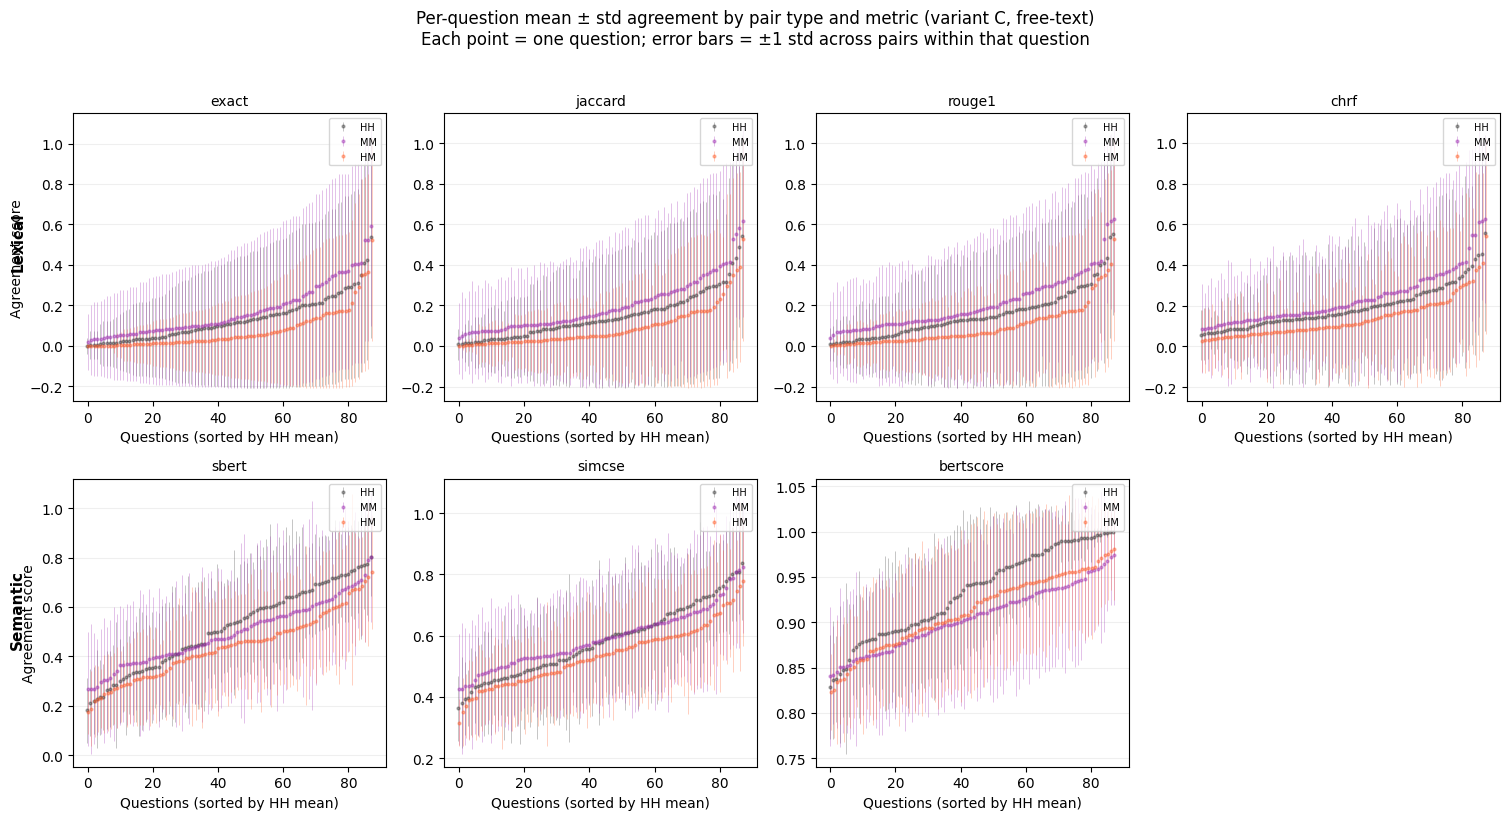

In [4]:
# ── Per-question mean ± std scatter: HH / MM / HM by metric ─────────────────
# Each point = one question. Shows both the central tendency and spread
# of agreement scores per metric, separated by pair type.

LEX_METRICS = [m for m in avail if m in ('exact', 'jaccard', 'rouge1', 'chrf')]
SEM_METRICS = [m for m in avail if m in ('sbert', 'simcse', 'bertscore')]

def plot_errbar_row(axes_row, metrics):
    for ax, m in zip(axes_row, metrics):
        q_stats = (
            C.groupby(['question_id', 'pair_type'])[m]
            .agg(['mean', 'std'])
            .reset_index()
        )
        offsets = {'HH': -0.15, 'MM': 0.0, 'HM': 0.15}
        for pt in PAIR_TYPES:
            sub = q_stats[q_stats['pair_type'] == pt].sort_values('mean').reset_index(drop=True)
            x = np.arange(len(sub)) + offsets[pt]
            ax.errorbar(x, sub['mean'], yerr=sub['std'].fillna(0),
                        fmt='o', color=COLORS[pt], alpha=0.4, ms=2,
                        elinewidth=0.5, capsize=0, label=pt)
        ax.set_title(m, fontsize=10)
        ax.set_xlabel('Questions (sorted by HH mean)')
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=7)
    for ax in axes_row[len(metrics):]:
        ax.set_visible(False)

n_cols = max(len(LEX_METRICS), len(SEM_METRICS))
fig, axes = plt.subplots(2, n_cols, figsize=(3.8 * n_cols, 8), sharey=False)

axes[0, 0].set_ylabel('Agreement score')
plot_errbar_row(axes[0], LEX_METRICS)
fig.text(0.01, 0.73, 'Lexical', va='center', rotation='vertical', fontsize=11, fontweight='bold')

axes[1, 0].set_ylabel('Agreement score')
plot_errbar_row(axes[1], SEM_METRICS)
fig.text(0.01, 0.27, 'Semantic', va='center', rotation='vertical', fontsize=11, fontweight='bold')

plt.suptitle('Per-question mean ± std agreement by pair type and metric (variant C, free-text)\n'
             'Each point = one question; error bars = ±1 std across pairs within that question',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 2. Metric correlation

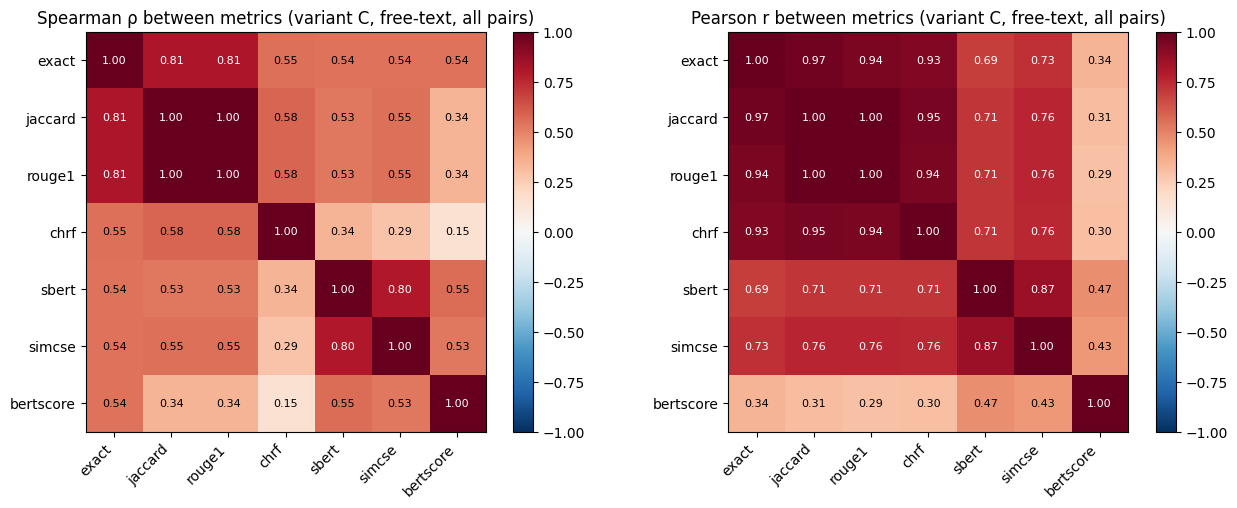


Spearman ρ matrix:


,exact,jaccard,rouge1,chrf,sbert,simcse,bertscore
exact,1.000,0.812,0.812,0.551,0.542,0.542,0.542
jaccard,0.812,1.000,1.000,0.581,0.526,0.550,0.340
rouge1,0.812,1.000,1.000,0.581,0.526,0.550,0.340
chrf,0.551,0.581,0.581,1.000,0.341,0.287,0.154
sbert,0.542,0.526,0.526,0.341,1.000,0.798,0.555
simcse,0.542,0.550,0.550,0.287,0.798,1.000,0.526
bertscore,0.542,0.340,0.340,0.154,0.555,0.526,1.000


In [5]:
# ── Pairwise metric correlation (Spearman, variant C) ─────────────────────────
corr_df = C[avail].copy()
spearman_mat = corr_df.corr(method='spearman')
pearson_mat  = corr_df.corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in zip(axes,
                           [spearman_mat, pearson_mat],
                           ['Spearman ρ', 'Pearson r']):
    im = ax.imshow(mat.values, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(avail))); ax.set_xticklabels(avail, rotation=45, ha='right')
    ax.set_yticks(range(len(avail))); ax.set_yticklabels(avail)
    for i in range(len(avail)):
        for j in range(len(avail)):
            v = mat.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if abs(v) > 0.6 else 'black')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'{title} between metrics (variant C, free-text, all pairs)')

plt.tight_layout()
plt.show()

print('\nSpearman ρ matrix:')
display(spearman_mat.round(3))

## 3. Length sensitivity

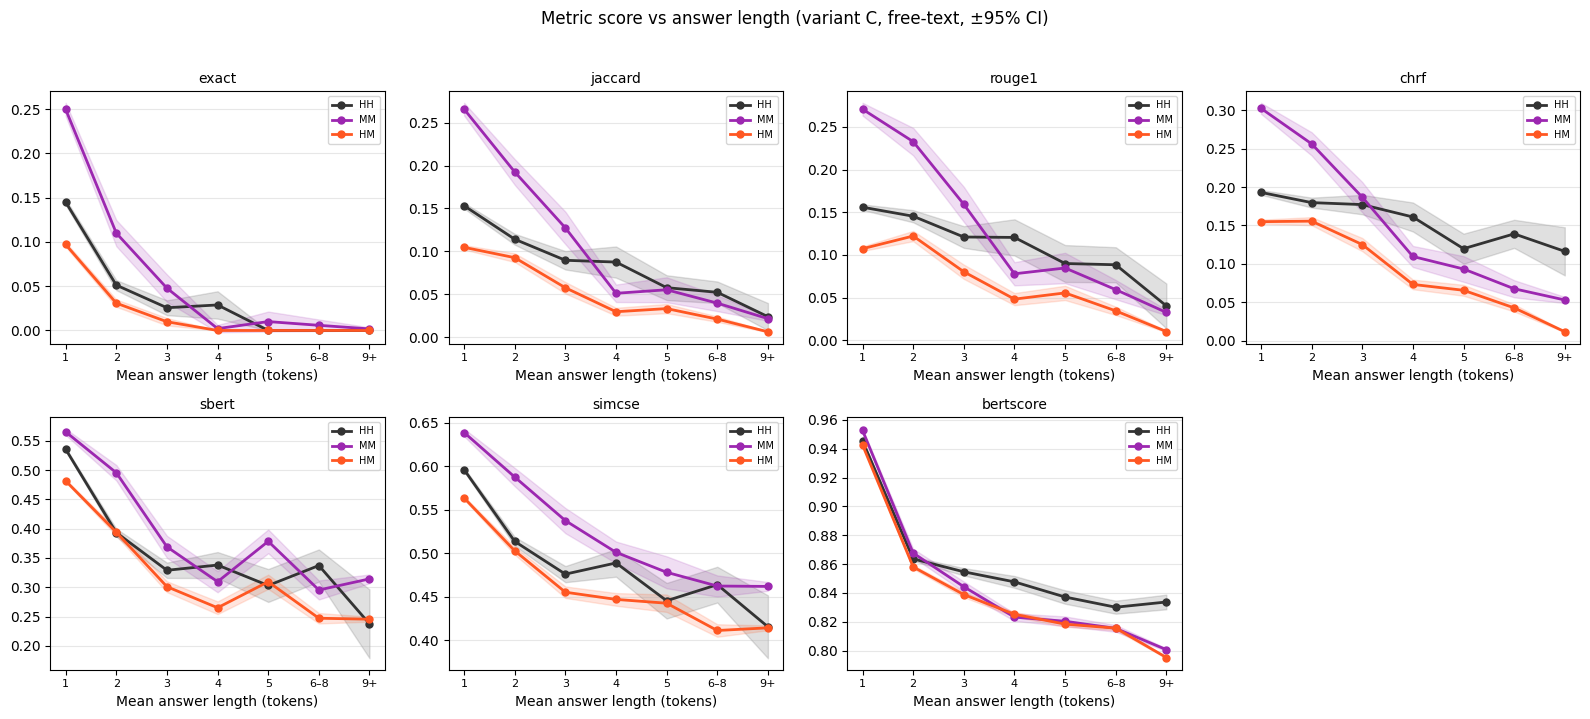

In [6]:
# ── Metric score vs answer length (mean token count) ─────────────────────────
# Bin pairs by mean answer length, compute mean score per bin.
# A length-robust metric should show a flat line.

length_bins = [1, 2, 3, 4, 5, 8, 15]
bin_labels  = ['1', '2', '3', '4', '5', '6–8', '9+']
C2 = C.copy()
C2['len_bin'] = pd.cut(
    C2['len_mean'],
    bins=[0, 1.5, 2.5, 3.5, 4.5, 5.5, 8.5, 100],
    labels=bin_labels
)

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for ax, m in zip(axes, avail):
    for pt in PAIR_TYPES:
        sub = C2[C2['pair_type'] == pt].groupby('len_bin', observed=True)[m]
        means = sub.mean()
        sems  = sub.sem()
        x = np.arange(len(means))
        ax.plot(x, means.values, 'o-', color=COLORS[pt], label=pt, lw=2, ms=5)
        ax.fill_between(x,
                        (means - 1.96 * sems).values,
                        (means + 1.96 * sems).values,
                        color=COLORS[pt], alpha=0.15)
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, fontsize=8)
    ax.set_xlabel('Mean answer length (tokens)')
    ax.set_title(m, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

# Hide spare axes
for ax in axes[len(avail):]:
    ax.set_visible(False)

plt.suptitle('Metric score vs answer length (variant C, free-text, ±95% CI)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# ── Spearman correlation between metric score and answer length ───────────────
# A perfectly length-robust metric has ρ ≈ 0.
print('Spearman ρ between metric score and mean answer length (variant C):')
print(f'{"metric":12s}  {"all pairs":>10s}  {"HH only":>10s}  {"HM only":>10s}')
for m in avail:
    r_all, _ = stats.spearmanr(C[m].dropna(), C.loc[C[m].notna(), 'len_mean'])
    hh = C[C['pair_type'] == 'HH']
    hm = C[C['pair_type'] == 'HM']
    r_hh, _ = stats.spearmanr(hh[m].dropna(), hh.loc[hh[m].notna(), 'len_mean'])
    r_hm, _ = stats.spearmanr(hm[m].dropna(), hm.loc[hm[m].notna(), 'len_mean'])
    print(f'{m:12s}  {r_all:+.3f}       {r_hh:+.3f}       {r_hm:+.3f}')

Spearman ρ between metric score and mean answer length (variant C):
metric         all pairs     HH only     HM only
exact         -0.232       -0.218       -0.204
jaccard       +0.026       -0.040       +0.073
rouge1        +0.026       -0.040       +0.073
chrf          +0.025       +0.117       +0.017
sbert         -0.390       -0.373       -0.398
simcse        -0.320       -0.300       -0.335
bertscore     -0.693       -0.588       -0.726


## 4. Discriminability: how well does each metric separate HH / MM / HM?

,mean_HH,mean_MM,mean_HM,gap_HH-HM,gap_HH-MM,d_HH-HM,d_HH-MM,p_HH>HM,p_HH≠MM
metric,,,,,,,,,
exact,0.130,0.173,0.076,0.055,-0.043,0.181,-0.120,2.31e-225,1.32e-50
jaccard,0.146,0.199,0.090,0.056,-0.053,0.182,-0.147,1.48e-80,0.00e+00
rouge1,0.153,0.210,0.097,0.057,-0.056,0.180,-0.154,1.02e-80,0.00e+00
chrf,0.191,0.236,0.137,0.053,-0.046,0.174,-0.130,2.28e-160,1.41e-23
sbert,0.512,0.493,0.438,0.074,0.019,0.282,0.066,0.00e+00,1.31e-36
simcse,0.583,0.592,0.536,0.046,-0.009,0.225,-0.041,1.44e-300,9.39e-01
bertscore,0.933,0.905,0.912,0.021,0.028,0.256,0.333,0.00e+00,0.00e+00


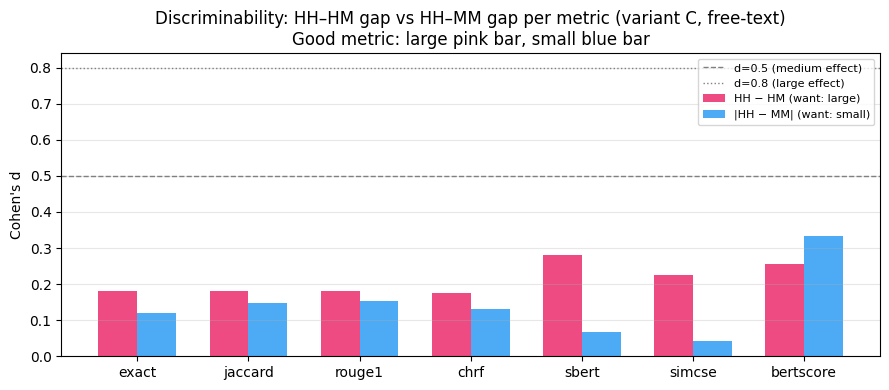

In [8]:
# ── Cohen's d and Mann-Whitney U: HH vs HM separation per metric ─────────────
# Cohen's d > 0.5 = medium effect, > 0.8 = large.
# A good metric should have large HH–HM separation and small HH–MM separation.

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    pooled_std = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0.0

rows = []
for m in avail:
    hh = C[C['pair_type'] == 'HH'][m].dropna().values
    mm = C[C['pair_type'] == 'MM'][m].dropna().values
    hm = C[C['pair_type'] == 'HM'][m].dropna().values
    
    d_hh_hm = cohens_d(hh, hm)
    d_hh_mm = cohens_d(hh, mm)
    u_hh_hm, p_hh_hm = stats.mannwhitneyu(hh, hm, alternative='greater')
    u_hh_mm, p_hh_mm = stats.mannwhitneyu(hh, mm, alternative='two-sided')

    rows.append({
        'metric':    m,
        'mean_HH':   round(hh.mean(), 3),
        'mean_MM':   round(mm.mean(), 3),
        'mean_HM':   round(hm.mean(), 3),
        'gap_HH-HM': round(hh.mean() - hm.mean(), 3),
        'gap_HH-MM': round(hh.mean() - mm.mean(), 3),
        'd_HH-HM':   round(d_hh_hm, 3),
        'd_HH-MM':   round(d_hh_mm, 3),
        'p_HH>HM':   f'{p_hh_hm:.2e}',
        'p_HH≠MM':   f'{p_hh_mm:.2e}',
    })

disc_df = pd.DataFrame(rows).set_index('metric')
display(disc_df)

# Visual: Cohen's d for HH–HM and HH–MM per metric
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(avail))
w = 0.35
b1 = ax.bar(x - w/2, disc_df['d_HH-HM'], width=w, color='#E91E63', alpha=0.8, label='HH − HM (want: large)')
b2 = ax.bar(x + w/2, disc_df['d_HH-MM'].abs(), width=w, color='#2196F3', alpha=0.8, label='|HH − MM| (want: small)')
ax.axhline(0.5, color='gray', ls='--', lw=1, label='d=0.5 (medium effect)')
ax.axhline(0.8, color='gray', ls=':', lw=1, label='d=0.8 (large effect)')
ax.set_xticks(x); ax.set_xticklabels(avail)
ax.set_ylabel("Cohen's d")
ax.set_title("Discriminability: HH–HM gap vs HH–MM gap per metric (variant C, free-text)\nGood metric: large pink bar, small blue bar")
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Correlation with human question difficulty

Questions with both scores and human accuracy: 88

Pearson r — per-question HH agreement vs human accuracy (variant C, free-text):
  exact         r=+0.600  p=6.69e-10  n=88
  jaccard       r=+0.518  p=2.34e-07  n=88
  rouge1        r=+0.476  p=2.81e-06  n=88
  chrf          r=+0.457  p=7.76e-06  n=88
  sbert         r=+0.464  p=5.15e-06  n=88
  simcse        r=+0.593  p=1.14e-09  n=88
  bertscore     r=+0.450  p=1.09e-05  n=88


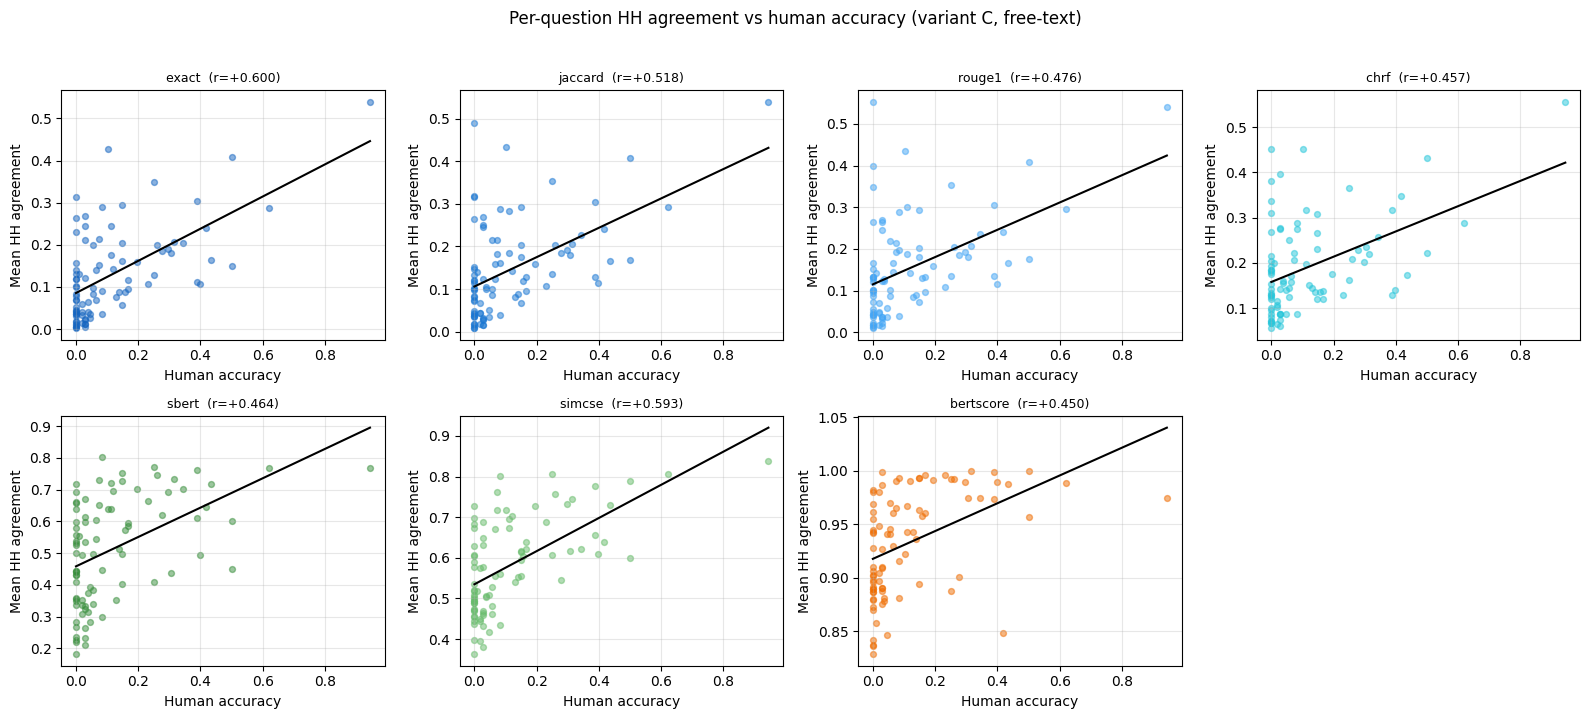

In [9]:
# ── Per-question mean score vs human accuracy ─────────────────────────────────
# Human accuracy = mean fraction correct across participants (from responses_human.csv).
# A reliable metric should correlate strongly with human accuracy
# (harder questions → lower inter-rater agreement).

h_csv = pd.read_csv(EXPORTS / 'responses_human.csv')
human_acc = (
    h_csv.groupby('question_id')['human_avg_acc']
    .first()
    .rename('human_acc')
    .reset_index()
)
human_acc['question_id'] = human_acc['question_id'].astype(str)

# Per-question mean score for HH pairs only (variant C)
hh_C = C[C['pair_type'] == 'HH'].copy()
hh_C['question_id'] = hh_C['question_id'].astype(str)
q_scores = hh_C.groupby('question_id')[avail].mean().reset_index()
merged = q_scores.merge(human_acc, on='question_id')

print(f'Questions with both scores and human accuracy: {len(merged)}')
print(f'\nPearson r — per-question HH agreement vs human accuracy (variant C, free-text):')
corrs = {}
for m in avail:
    sub = merged[['human_acc', m]].dropna()
    r, p = stats.pearsonr(sub['human_acc'], sub[m])
    corrs[m] = r
    print(f'  {m:12s}  r={r:+.3f}  p={p:.2e}  n={len(sub)}')

# Scatter plots
n_m = len(avail)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, m in zip(axes, avail):
    sub = merged[['human_acc', m]].dropna()
    ax.scatter(sub['human_acc'], sub[m], alpha=0.5, s=18, color=METRIC_COLORS.get(m, 'steelblue'))
    m_coef, b_coef = np.polyfit(sub['human_acc'], sub[m], 1)
    xs = np.linspace(sub['human_acc'].min(), sub['human_acc'].max(), 50)
    ax.plot(xs, m_coef * xs + b_coef, color='black', lw=1.5)
    r = corrs[m]
    ax.set_title(f'{m}  (r={r:+.3f})', fontsize=9)
    ax.set_xlabel('Human accuracy')
    ax.set_ylabel('Mean HH agreement')
    ax.grid(alpha=0.3)
for ax in axes[n_m:]:
    ax.set_visible(False)

plt.suptitle('Per-question HH agreement vs human accuracy (variant C, free-text)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 6. Variant robustness: does metric ranking hold across C / B / A?

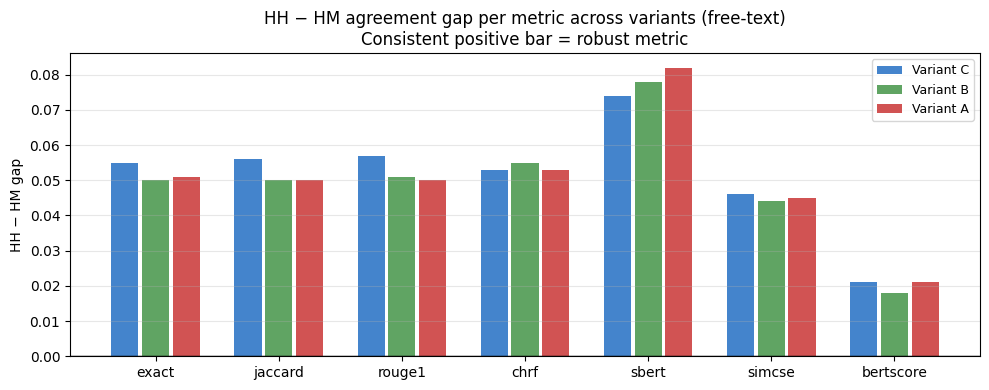

variant,C,B,A
metric,,,
bertscore,0.021,0.018,0.021
chrf,0.053,0.055,0.053
exact,0.055,0.050,0.051
jaccard,0.056,0.050,0.050
rouge1,0.057,0.051,0.050
sbert,0.074,0.078,0.082
simcse,0.046,0.044,0.045


In [10]:
# ── HH–HM gap stability across variants ──────────────────────────────────────
# A reliable metric should show the same relative ordering (HH > HM) across all variants.

rows = []
for var in VARIANT_ORDER:
    sub = pairs[pairs['variant'] == var]
    for m in avail:
        hh = sub[sub['pair_type'] == 'HH'][m].mean()
        mm = sub[sub['pair_type'] == 'MM'][m].mean()
        hm = sub[sub['pair_type'] == 'HM'][m].mean()
        rows.append({'variant': var, 'metric': m,
                     'HH': round(hh, 3), 'MM': round(mm, 3), 'HM': round(hm, 3),
                     'gap_HH-HM': round(hh - hm, 3)})

var_df = pd.DataFrame(rows)

# Plot: gap across variants per metric
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(avail))
offsets = np.linspace(-0.25, 0.25, len(VARIANT_ORDER))
var_colors = {'C': '#1565C0', 'B': '#388E3C', 'A': '#C62828'}
for i, var in enumerate(VARIANT_ORDER):
    gaps = [var_df[(var_df['variant'] == var) & (var_df['metric'] == m)]['gap_HH-HM'].values[0]
            for m in avail]
    ax.bar(x + offsets[i], gaps, width=0.22, color=var_colors[var], alpha=0.8, label=f'Variant {var}')
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x); ax.set_xticklabels(avail)
ax.set_ylabel('HH − HM gap')
ax.set_title('HH − HM agreement gap per metric across variants (free-text)\nConsistent positive bar = robust metric')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(var_df.pivot_table(index='metric', columns='variant', values='gap_HH-HM').round(3)[VARIANT_ORDER])

## 7. Summary: metric scorecard

In [11]:
# ── Scorecard: rank each metric on each reliability criterion ─────────────────

# 1. Correlation with human accuracy (higher = better)
acc_corr = {m: corrs.get(m, np.nan) for m in avail}

# 2. HH–HM discriminability Cohen's d (higher = better)
d_hh_hm = disc_df['d_HH-HM'].to_dict()

# 3. |HH–MM| Cohen's d (lower = better — we don't want the metric to penalise model-model)
d_hh_mm_abs = disc_df['d_HH-MM'].abs().to_dict()

# 4. Length sensitivity: |Spearman ρ with length| (lower = better)
len_rho = {}
for m in avail:
    sub = C[['len_mean', m]].dropna()
    rho, _ = stats.spearmanr(sub['len_mean'], sub[m])
    len_rho[m] = abs(rho)

# 5. Variant stability: std of gap across variants (lower = better)
gap_std = {}
for m in avail:
    gaps = var_df[var_df['metric'] == m]['gap_HH-HM'].values
    gap_std[m] = np.std(gaps)

score_df = pd.DataFrame({
    'acc_corr (↑)':    acc_corr,
    'd_HH-HM (↑)':    d_hh_hm,
    'd_HH-MM (↓)':    d_hh_mm_abs,
    'len_sensitivity (↓)': len_rho,
    'variant_instability (↓)': gap_std,
}).round(3)

print('Metric reliability scorecard (variant C, free-text):')
print('↑ = higher is better, ↓ = lower is better')
display(score_df)

# Normalised rank (0=worst, 1=best) for radar-style comparison
def rank_col(col, higher_is_better=True):
    r = col.rank()
    if higher_is_better:
        return (r - 1) / (len(r) - 1)
    else:
        return 1 - (r - 1) / (len(r) - 1)

ranked = pd.DataFrame({
    'acc_corr':         rank_col(score_df['acc_corr (↑)'],   higher_is_better=True),
    'd_HH-HM':         rank_col(score_df['d_HH-HM (↑)'],   higher_is_better=True),
    'd_HH-MM (inv)':   rank_col(score_df['d_HH-MM (↓)'],   higher_is_better=False),
    'len_robust':       rank_col(score_df['len_sensitivity (↓)'], higher_is_better=False),
    'var_stable':       rank_col(score_df['variant_instability (↓)'], higher_is_better=False),
})
ranked['overall'] = ranked.mean(axis=1)
ranked = ranked.sort_values('overall', ascending=False)
print('\nNormalised rank (0=worst, 1=best):')
display(ranked.round(3))

Metric reliability scorecard (variant C, free-text):
↑ = higher is better, ↓ = lower is better


,acc_corr (↑),d_HH-HM (↑),d_HH-MM (↓),len_sensitivity (↓),variant_instability (↓)
exact,0.600,0.181,0.120,0.232,0.002
jaccard,0.518,0.182,0.147,0.026,0.003
rouge1,0.476,0.180,0.154,0.026,0.003
chrf,0.457,0.174,0.130,0.025,0.001
sbert,0.464,0.282,0.066,0.390,0.003
simcse,0.593,0.225,0.041,0.320,0.001
bertscore,0.450,0.256,0.333,0.693,0.001



Normalised rank (0=worst, 1=best):


,acc_corr,d_HH-HM,d_HH-MM (inv),len_robust,var_stable,overall
simcse,0.833,0.667,1.000,0.333,0.833,0.733
exact,1.000,0.333,0.667,0.500,0.500,0.600
chrf,0.167,0.000,0.500,1.000,0.833,0.500
sbert,0.333,1.000,0.833,0.167,0.167,0.500
jaccard,0.667,0.500,0.333,0.750,0.167,0.483
rouge1,0.500,0.167,0.167,0.750,0.167,0.350
bertscore,0.000,0.833,0.000,0.000,0.833,0.333
